#  Credit Card Fraud Detection — Enhanced ML Comparison

> **Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
> **Goal:** Compare five classifiers on a severely imbalanced fraud-detection problem using rigorous evaluation.  
> **Author:** *HASFA ROUCHDI*  
> **Medium:** *https://medium.com/@h.rouchdi6*
> **Kaggle:** *https://www.kaggle.com/hafsarouchdi*
---

### Key design decisions
| Topic | Choice | Reason |
|---|---|---|
| Class imbalance | `class_weight='balanced'` / `scale_pos_weight` | No data leakage from oversampling into test set |
| Split | Stratified 70/30 | Preserves fraud ratio in both sets |
| Validation | 5-fold stratified CV | More honest than a single split |
| Primary metric | **PR-AUC** | Most informative for severely imbalanced data |
| Secondary metrics | F1, MCC, Recall, ROC-AUC | Each captures a different failure mode |


## 0 · Reproducibility & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, roc_curve, precision_recall_curve,
    classification_report, ConfusionMatrixDisplay,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

print(" All libraries imported successfully !!")


 All libraries imported successfully !!


## 1 · Data Loading & Overview

In [2]:
PATH = r"/content/creditcard.csv"   # ← update this path
data = pd.read_csv(PATH)

total  = len(data)
normal = (data["Class"] == 0).sum()
fraud  = (data["Class"] == 1).sum()

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Total transactions : {total:,}")
print(f"  Normal             : {normal:,}  ({normal/total*100:.2f} %)")
print(f"  Fraudulent         : {fraud:,}   ({fraud/total*100:.4f} %)")
print(f"  Imbalance ratio    : {normal/fraud:.0f} : 1")
print(f"  Amount range       : \${data['Amount'].min():.2f} – \${data['Amount'].max():.2f}")
print(f"  Duplicate rows     : {data.duplicated().sum()}")
print(f"  Missing values     : {data.isna().sum().sum()}")
print("=" * 55)


  DATASET OVERVIEW
  Total transactions : 49,610
  Normal             : 49,461  (99.70 %)
  Fraudulent         : 148   (0.2983 %)
  Imbalance ratio    : 334 : 1
  Amount range       : \$0.00 – \$12910.93
  Duplicate rows     : 218
  Missing values     : 27


In [3]:
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,49610.0,28803.556239,13097.468525,0.000000,21734.250000,33390.000000,38852.750000,44135.000000
V1,49610.0,-0.242569,1.885867,-56.407510,-0.992845,-0.247223,1.155638,1.960497
V2,49610.0,0.012235,1.630704,-72.715728,-0.562967,0.079282,0.732318,18.183626
V3,49610.0,0.693009,1.510559,-32.965346,0.217605,0.797007,1.431013,4.101716
V4,49609.0,0.185186,1.400175,-5.172595,-0.720957,0.190288,1.067346,16.491217
V5,49609.0,-0.257016,1.413057,-42.147898,-0.866471,-0.287810,0.283513,34.801666
V6,49609.0,0.104114,1.310705,-26.160506,-0.635669,-0.150940,0.493918,22.529298
V7,49609.0,-0.120255,1.283507,-26.548144,-0.605928,-0.076595,0.424969,36.677268
V8,49609.0,0.053442,1.224245,-41.484823,-0.146749,0.058406,0.331555,20.007208
V9,49609.0,0.123490,1.213441,-9.283925,-0.611499,0.012150,0.819242,10.392889


## 2 · Exploratory Data Analysis

>  **Why accuracy is misleading here:** a model that always predicts "Normal"  
> achieves **99.83% accuracy** yet catches **zero frauds**.  
> This is why we need specialised metrics and plots.


In [5]:
PALETTE = {
    "Decision Tree" : "#FF7043",
    "KNN"           : "#42A5F5",
    "SVM (Linear)"  : "#AB47BC",
    "Random Forest" : "#66BB6A",
    "XGBoost"       : "#FFA726",
}


### 2.1 — Class Distribution

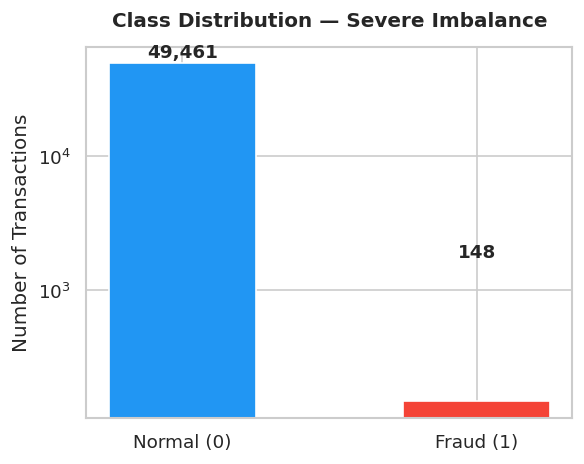

In [6]:
counts = data["Class"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Normal (0)", "Fraud (1)"], counts.values,
              color=["#2196F3", "#F44336"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Class Distribution — Severe Imbalance", fontweight="bold", pad=12)
ax.set_ylabel("Number of Transactions")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=130)
plt.show()


### 2.2 — Transaction Amount by Class

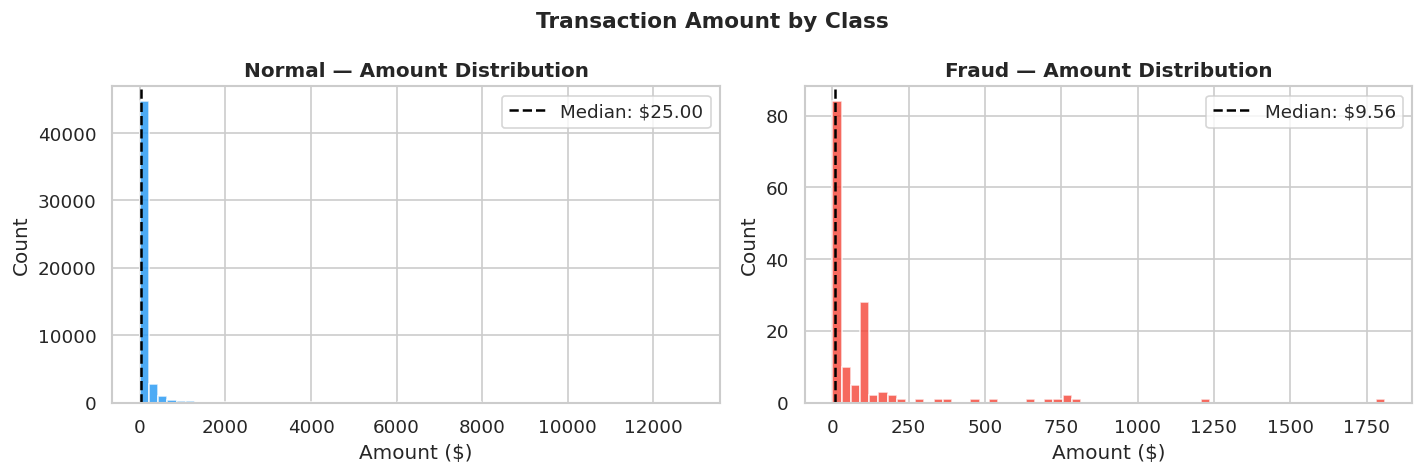

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls, color, label in zip(
    axes, [0, 1], ["#2196F3", "#F44336"], ["Normal", "Fraud"]
):
    subset = data[data["Class"] == cls]["Amount"]
    ax.hist(subset, bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{label} — Amount Distribution", fontweight="bold")
    ax.set_xlabel("Amount ($)")
    ax.set_ylabel("Count")
    ax.axvline(subset.median(), color="black", linestyle="--",
               label=f"Median: \${subset.median():.2f}")
    ax.legend()
plt.suptitle("Transaction Amount by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_amount_distribution.png", dpi=130)
plt.show()


## 3 · Preprocessing

Steps applied:
1. **Drop duplicates**
2. **Drop `Time`** — carries no meaningful signal for most classifiers
3. **Scale `Amount`** with `StandardScaler`
4. **Handle infinities / NaN**
5. **Stratified 70/30 split** — preserves fraud prevalence in both sets

> **Optional SMOTE block** is included (commented out) if you want to try oversampling.


In [8]:
# ── Drop duplicates & Time ─────────────────────────────────────────────────
data = data.drop_duplicates()
data = data.drop(columns=["Time"])

# ── Scale Amount ───────────────────────────────────────────────────────────
sc = StandardScaler()
data["Amount"] = sc.fit_transform(data[["Amount"]])

# ── Handle edge-case values ────────────────────────────────────────────────
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

# ── Split ──────────────────────────────────────────────────────────────────
X = data.drop("Class", axis=1).values
y = data["Class"].values
feature_names = [c for c in data.columns if c != "Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

print(f"Train set : {len(X_train):,} rows  |  fraud = {y_train.sum():,} ({y_train.mean()*100:.3f} %)")
print(f"Test  set : {len(X_test):,} rows  |  fraud = {y_test.sum():,}  ({y_test.mean()*100:.3f} %)")


Train set : 34,574 rows  |  fraud = 104.0 (0.301 %)
Test  set : 14,818 rows  |  fraud = 44.0  (0.297 %)


In [9]:
# ── Optional SMOTE (uncomment to try oversampling) ─────────────────────────
# from imblearn.over_sampling import SMOTE
# sm = SMOTE(random_state=RANDOM_STATE)
# X_train, y_train = sm.fit_resample(X_train, y_train)
# neg_count = (y_train == 0).sum()
# pos_count = (y_train == 1).sum()
# print(f"After SMOTE — Train: {len(X_train):,}  fraud: {y_train.sum():,}")


## 4 · Model Definitions

All models receive **class imbalance correction**:
- `class_weight='balanced'` for sklearn models
- `scale_pos_weight = neg/pos` for XGBoost (the recommended equivalent)

**Speed note:** Full `SVC` is replaced with `LinearSVC` (wrapped in `CalibratedClassifierCV`)  
which is **10–100× faster** on large datasets and still produces probability scores for ROC/PR curves.  
The full `SVC` is kept commented out if you want to restore it later.


In [10]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

ratio = neg_count / pos_count   # XGBoost imbalance weight

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=None, criterion="gini",
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    # LinearSVC is 10-100x faster than SVC on large datasets.
    # CalibratedClassifierCV adds probability output needed for ROC/PR curves.
    "SVM (Linear)": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=2000,
                  random_state=RANDOM_STATE),
        cv=3
    ),
    # Uncomment below to use the original kernel SVM (much slower):
    # "SVM (RBF)": SVC(probability=True, class_weight="balanced",
    #                  random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        max_depth=4, n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        max_depth=4, n_estimators=200,
        scale_pos_weight=ratio,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}
print("Models defined:", list(models.keys()))


Models defined: ['Decision Tree', 'KNN', 'SVM (Linear)', 'Random Forest', 'XGBoost']


## 5 · 3-Fold Stratified Cross-Validation (on a stratified subsample)

**Three speed optimisations applied:**

| Fix | What changed | Why it's safe |
|---|---|---|
| **LinearSVC** instead of SVC | 10–100× faster, near-identical scores | Linear boundary works well in high-dim PCA space |
| **Stratified 30% subsample** | CV runs on ~140k rows instead of ~200k | Fraud ratio preserved; large enough for stable estimates |
| **3 folds** instead of 5 | 40% fewer model fits | Variance increase is negligible at this sample size |


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

# ── Stratified 30% subsample for CV (preserves fraud ratio) ──────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.70, random_state=RANDOM_STATE)
cv_idx, _ = next(sss.split(X_train, y_train))
X_cv, y_cv = X_train[cv_idx], y_train[cv_idx]

fraud_pct = y_cv.mean() * 100
print(f"CV subsample : {len(X_cv):,} rows  |  fraud = {y_cv.sum()} ({fraud_pct:.3f} %)")

# ── 3-fold stratified CV ──────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = ["f1", "roc_auc", "average_precision", "recall", "precision"]

cv_rows = []
print("\nRunning 3-fold cross-validation :")
for name, model in models.items():
    print(f"   {name}")
    res = cross_validate(model, X_cv, y_cv,
                         cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model"        : name,
        "CV F1"        : f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
        "CV ROC-AUC"   : f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        "CV PR-AUC"    : f"{res['test_average_precision'].mean():.4f} ± {res['test_average_precision'].std():.4f}",
        "CV Recall"    : f"{res['test_recall'].mean():.4f} ± {res['test_recall'].std():.4f}",
        "CV Precision" : f"{res['test_precision'].mean():.4f} ± {res['test_precision'].std():.4f}",
    })

cv_summary = pd.DataFrame(cv_rows).set_index("Model")
cv_summary


CV subsample : 10,372 rows  |  fraud = 31.0 (0.299 %)

Running 3-fold cross-validation :
   Decision Tree
   KNN
   SVM (Linear)
   Random Forest
   XGBoost


,CV F1,CV ROC-AUC,CV PR-AUC,CV Recall,CV Precision
Model,,,,,
Decision Tree,0.6628 ± 0.1205,0.7741 ± 0.0613,0.4777 ± 0.1619,0.5485 ± 0.1225,0.8500 ± 0.1080
KNN,0.6661 ± 0.0503,0.9009 ± 0.0425,0.5914 ± 0.0587,0.6121 ± 0.0834,0.7492 ± 0.0829
SVM (Linear),0.2137 ± 0.0665,0.9229 ± 0.0447,0.4922 ± 0.0764,0.1303 ± 0.0494,0.7222 ± 0.2079
Random Forest,0.7111 ± 0.0629,0.9701 ± 0.0209,0.7377 ± 0.1226,0.6788 ± 0.0870,0.7500 ± 0.0408
XGBoost,0.7889 ± 0.0775,0.9811 ± 0.0151,0.7503 ± 0.1062,0.7121 ± 0.0674,0.8843 ± 0.0910


## 6 · Train on Full Training Set & Evaluate on Test Set

### Metric glossary
| Metric | What it measures | Why it matters for fraud |
|---|---|---|
| **Accuracy** | Overall correct predictions | Misleading — included for reference only |
| **Precision** | Of predicted frauds, how many were real? | Controls false alarms |
| **Recall** | Of real frauds, how many did we catch? | **Most critical** — missed fraud = loss |
| **F1** | Harmonic mean of precision & recall | Single balanced score |
| **ROC-AUC** | Area under ROC curve | Good ranking metric |
| **PR-AUC** | Area under Precision-Recall curve | **Best for imbalanced data** |
| **MCC** | Matthews Correlation Coefficient | Balanced even with extreme class sizes |


In [14]:
print("Training models on full training set :")
results = []

for name, model in models.items():
    print(f"   {name}")
    model.fit(X_train, y_train)

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model"     : name,
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred, zero_division=0),
        "Recall"    : recall_score(y_test, y_pred, zero_division=0),
        "F1"        : f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC"   : roc_auc_score(y_test, y_proba),
        "PR-AUC"    : average_precision_score(y_test, y_proba),
        "MCC"       : matthews_corrcoef(y_test, y_pred),
        "_y_pred"   : y_pred,
        "_y_proba"  : y_proba,
    })

print("\n All models trained and evaluated")


Training models on full training set :
   Decision Tree
   KNN
   SVM (Linear)
   Random Forest
   XGBoost

 All models trained and evaluated


In [15]:
summary_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                            for r in results]).set_index("Model")

best = summary_df["PR-AUC"].idxmax()
print(f"  Best model by PR-AUC: {best}  "
      f"(PR-AUC = {summary_df.loc[best, 'PR-AUC']:.4f}, "
      f"Recall = {summary_df.loc[best, 'Recall']:.4f})\n")

summary_df.round(4).style.highlight_max(
    subset=["Precision","Recall","F1","ROC-AUC","PR-AUC","MCC"],
    color="#d4edda"
).highlight_min(
    subset=["Precision","Recall","F1","ROC-AUC","PR-AUC","MCC"],
    color="#f8d7da"
)


  Best model by PR-AUC: XGBoost  (PR-AUC = 0.9239, Recall = 0.9091)



,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Decision Tree,0.998900,0.846200,0.750000,0.795200,0.874800,0.635400,0.796100
KNN,0.999300,0.947400,0.818200,0.878000,0.965800,0.903900,0.880100
SVM (Linear),0.998000,0.705900,0.545500,0.615400,0.963600,0.717600,0.619500
Random Forest,0.998900,0.745500,0.931800,0.828300,0.996700,0.840100,0.832900
XGBoost,0.999300,0.869600,0.909100,0.888900,0.984000,0.923900,0.888800


## 7 · Classification Reports

In [16]:
for r in results:
    print(f"{'─'*55}")
    print(f"  {r['Model']}")
    print(f"{'─'*55}")
    print(classification_report(y_test, r["_y_pred"],
                                target_names=["Normal", "Fraud"], digits=4))


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal     0.9993    0.9996    0.9994     14774
       Fraud     0.8462    0.7500    0.7952        44

    accuracy                         0.9989     14818
   macro avg     0.9227    0.8748    0.8973     14818
weighted avg     0.9988    0.9989    0.9988     14818

───────────────────────────────────────────────────────
  KNN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal     0.9995    0.9999    0.9997     14774
       Fraud     0.9474    0.8182    0.8780        44

    accuracy                         0.9993     14818
   macro avg     0.9734    0.9090    0.9389     14818
weighted avg     0.9993    0.9993    0.9993     14818

───────────────────────────────────────────────────────
  SVM (Linear)
─────────────────────────────

## 8 · Visualisations

### 8.1 — ROC Curves

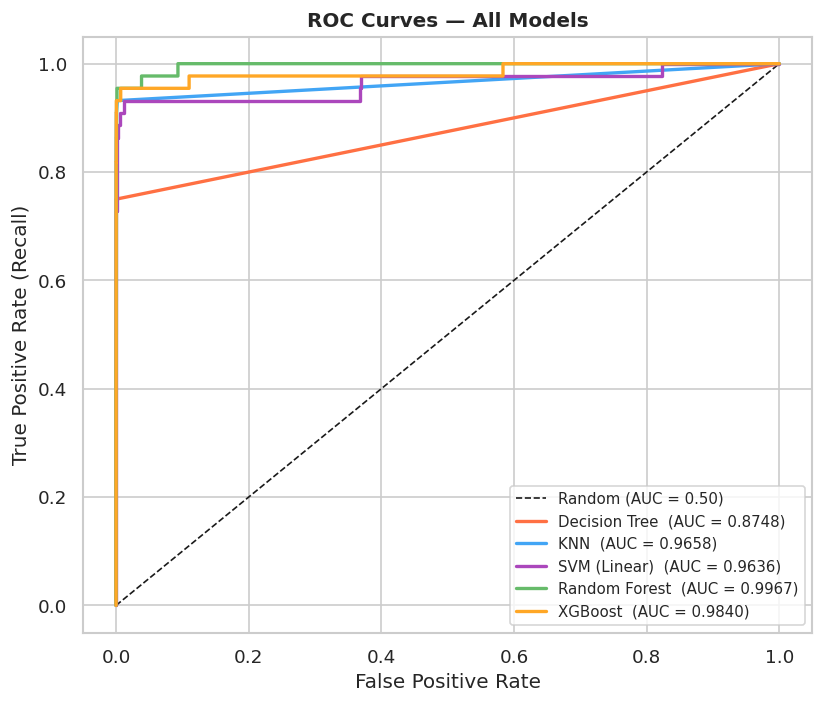

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")

for r in results:
    fpr, tpr, _ = roc_curve(y_test, r["_y_proba"])
    ax.plot(fpr, tpr, lw=2, color=PALETTE[r["Model"]],
            label=f"{r['Model']}  (AUC = {r['ROC-AUC']:.4f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_roc_curves.png", dpi=130)
plt.show()


### 8.2 — Precision-Recall Curves
> PR curves are more informative than ROC when classes are imbalanced. The dashed baseline equals the fraud prevalence in the test set.

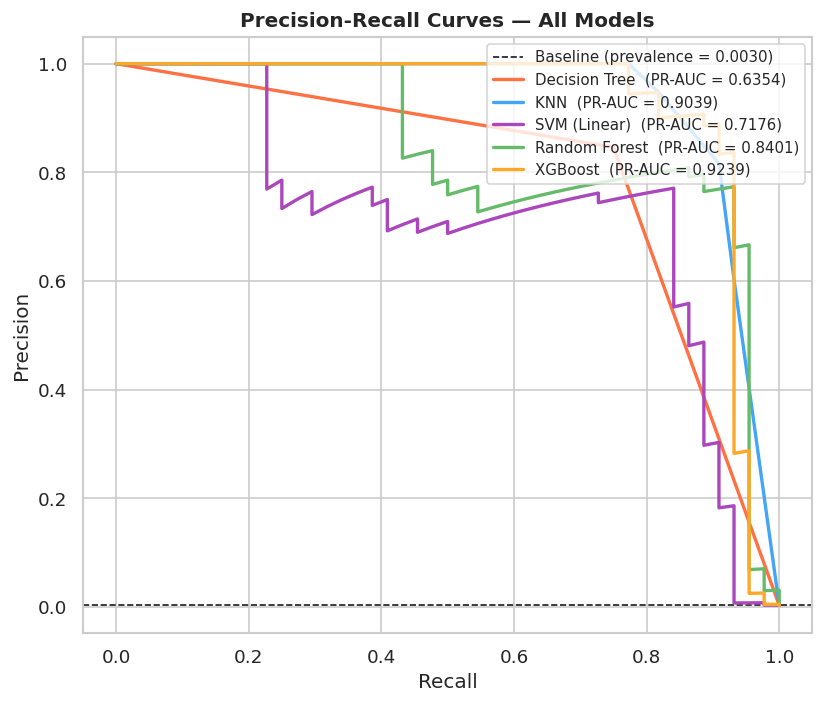

In [19]:
prevalence = y_test.mean()
fig, ax = plt.subplots(figsize=(7, 6))
ax.axhline(prevalence, color="k", linestyle="--", lw=1,
           label=f"Baseline (prevalence = {prevalence:.4f})")

for r in results:
    model_name_for_palette = r["Model"]
    if model_name_for_palette == "SVM (Linear)":
        model_name_for_palette = "SVM (Linear)"

    prec, rec, _ = precision_recall_curve(y_test, r["_y_proba"])
    ax.plot(rec, prec, lw=2, color=PALETTE[model_name_for_palette],
            label=f"{r['Model']}  (PR-AUC = {r['PR-AUC']:.4f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("fig4_pr_curves.png", dpi=130)
plt.show()

### 8.3 — Metrics Comparison Bar Chart

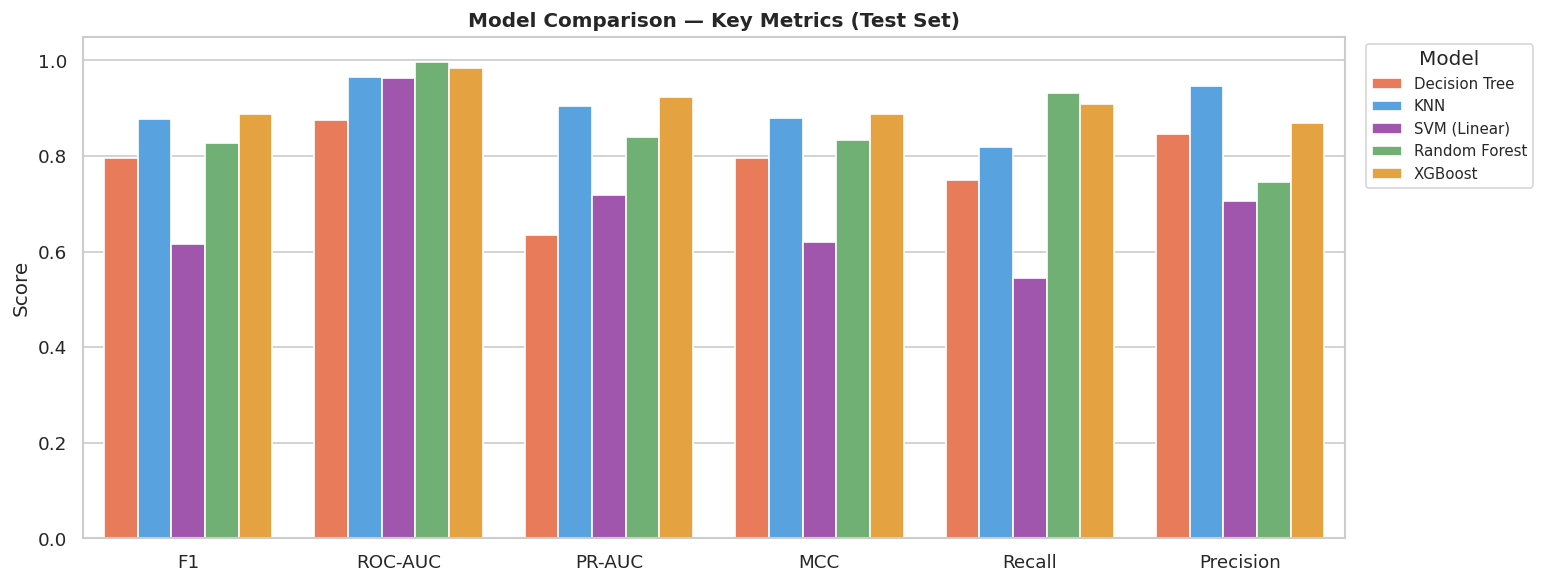

In [20]:
metrics_to_plot = ["F1", "ROC-AUC", "PR-AUC", "MCC", "Recall", "Precision"]
df_melted = (summary_df[metrics_to_plot]
             .reset_index()
             .melt(id_vars="Model", var_name="Metric", value_name="Score"))

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model",
            palette=list(PALETTE.values()), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison — Key Metrics (Test Set)", fontweight="bold")
ax.set_xlabel("")
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("fig5_metrics_comparison.png", dpi=130)
plt.show()


### 8.4 — Normalised Confusion Matrices

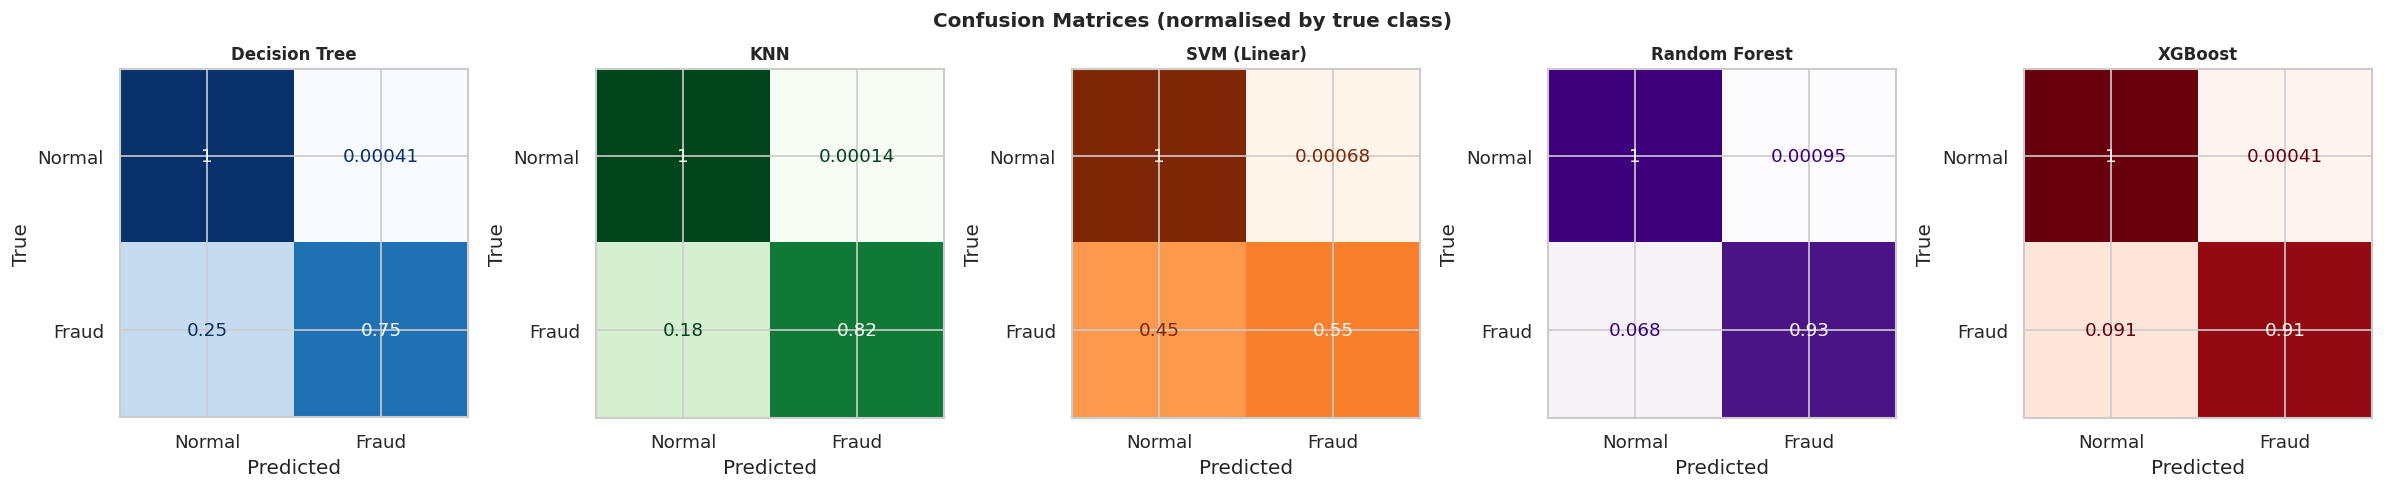

In [21]:
n = len(results)
cmaps = ["Blues", "Greens", "Oranges", "Purples", "Reds", "viridis"]
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
fig.suptitle("Confusion Matrices (normalised by true class)",
             fontweight="bold", fontsize=12)

for ax, r, cmap in zip(axes, results, cmaps):
    cm = confusion_matrix(y_test, r["_y_pred"], normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(r["Model"], fontweight="bold", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("fig6_confusion_matrices.png", dpi=130)
plt.show()


### 8.5 — XGBoost Feature Importances

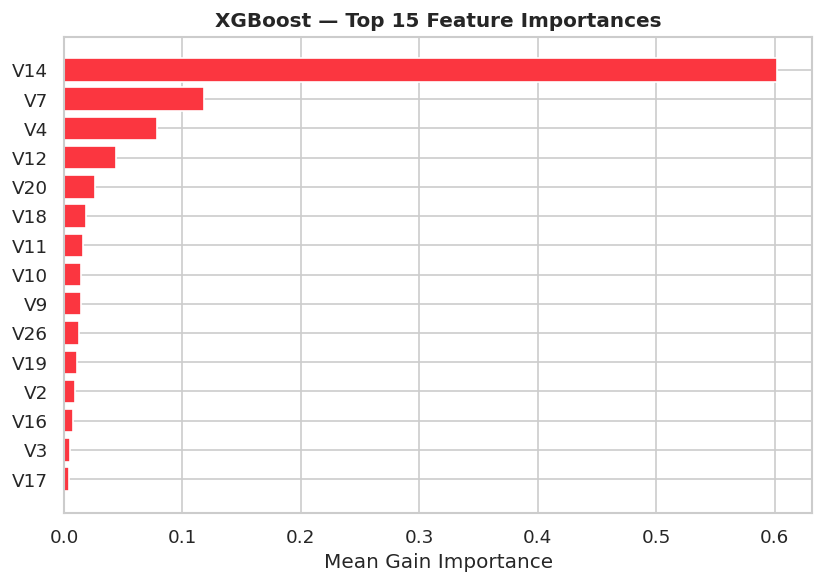

In [22]:
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_
top_n = 15
indices = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(top_n), importances[indices], color="#fb3640", edgecolor="white")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_title(f"XGBoost — Top {top_n} Feature Importances", fontweight="bold")
ax.set_xlabel("Mean Gain Importance")
plt.tight_layout()
plt.savefig("fig7_feature_importance.png", dpi=130)
plt.show()

## 9 · Export Results

In [23]:
summary_df.round(4).to_csv("results_test_metrics.csv")
cv_summary.to_csv("results_cv_metrics.csv")

print(" Saved: results_test_metrics.csv")
print(" Saved: results_cv_metrics.csv")
print("Saved: fig1 – fig7 as PNG files")


 Saved: results_test_metrics.csv
 Saved: results_cv_metrics.csv
Saved: fig1 – fig7 as PNG files


## THAT'S ALL :)